In [2]:
#imports
import math
import numpy as np
import torch

from matplotlib import pyplot as plt

from linear_simulation import TheorySimulator

/home/maherhanut/Documents/Low-Dimensional-Feedback/scripts/linear_simulation.py:165: SyntaxWarning: invalid escape sequence '\h'
  axs.set_ylabel('$\hat{\sigma}$', fontsize=23)


In [3]:
#Define global constants that will be used throughout the simulations 
device = 'cuda'
P = 100000

n = 128
k = 64
m = 64

# LDFA Simulation for r >= m

In [15]:
X = torch.normal(0, 1, (n, P)).to(device)
W_gt = torch.normal(0, 1, (m, 32)) @ torch.normal(0, 1, (32, n)) / math.sqrt(64)
W_gt = W_gt.to(device)
y = W_gt @ X
sigma_io = (1/(P)) * (y @ X.T) 

U, sig_io, V_t = torch.linalg.svd(sigma_io)
sig_mat_io = U.T @ sigma_io @ V_t.T

<>:21: SyntaxWarning: invalid escape sequence '\h'
<>:21: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_475385/3642385171.py:21: SyntaxWarning: invalid escape sequence '\h'
  axs.set_ylabel('$\hat{\sigma}$', fontsize=23)
100%|██████████| 5000/5000 [00:03<00:00, 1389.81it/s]


tensor(0.0045, device='cuda:0')


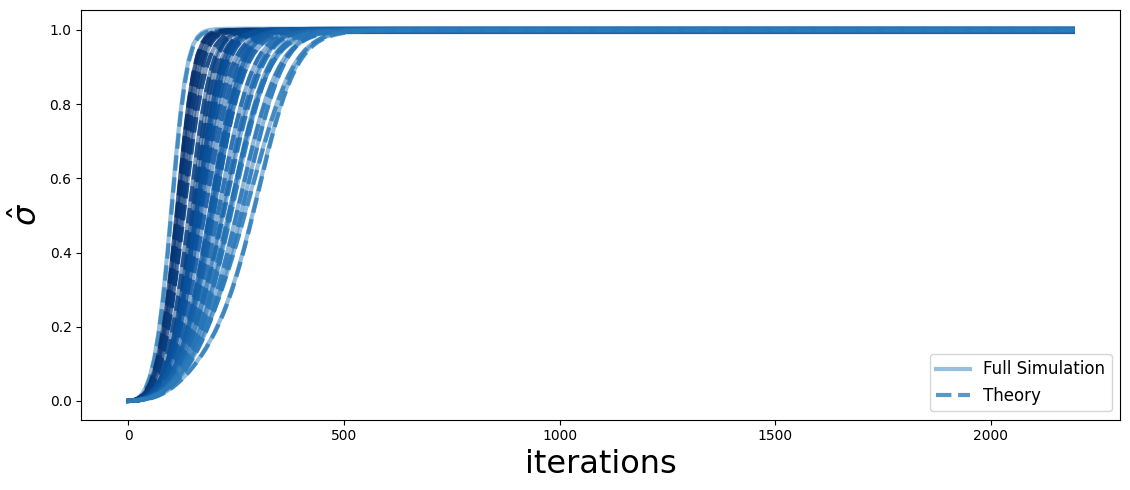

In [23]:
SimulationObj = TheorySimulator(n, k, m, U=U, V_t = V_t, sig_mat_io = sig_mat_io, rank=m, lr=4e-3, bw_lr=1.3e-3, lamb=1e-12, num_iterations=5000, update_QP=True, device='cuda')
singulars_sim, singulars_theory = np.array(SimulationObj.train(X = X, y=y))

fig, axs = plt.subplots(1, 1, figsize=(11.4, 5)) 
s = 32
lim = 220
# Create color mapsac
blue_colors = plt.cm.Blues(np.linspace(0.7, 1,s))
green_colors = plt.cm.Greens(np.linspace(0.65, 0.9,s))
red_colors = plt.cm.Reds(np.linspace(0.4, 1,s))

X_range = np.arange(len(singulars_sim[:, 0])) * 10

for j in range(s):
    # ax.plot(singulars_BP[i, :, j], color=blue_colors[j], label='BP' if j == 0 else "")
    axs.plot(X_range[:lim], singulars_sim[:lim, j] , color=blue_colors[-j], linewidth=3, alpha=0.5)
    axs.plot(X_range[:lim], singulars_theory[:lim, j] , color=blue_colors[-j], linewidth=3, alpha=0.8, linestyle='--')
    # axs.plot(X[:lim], singulars_FA[:lim, j]  , color=green_colors[0], linewidth=2, linestyle='--')

axs.set_xlabel('iterations', fontsize=23)
axs.set_ylabel('$\hat{\sigma}$', fontsize=23)
axs.legend(['Full Simulation', 'Theory'], loc='lower right', fontsize=12, ncol=1)

plt.tight_layout()
# plt.show()
plt.savefig('normative_approach_r_equals_m.svg')

# LDFA Simulation with r < m

<>:21: SyntaxWarning: invalid escape sequence '\h'
<>:21: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_475385/13859329.py:21: SyntaxWarning: invalid escape sequence '\h'
  axs.set_ylabel('$\hat{\sigma}$', fontsize=23)
100%|██████████| 5000/5000 [00:03<00:00, 1423.57it/s]


tensor(15.8850, device='cuda:0')


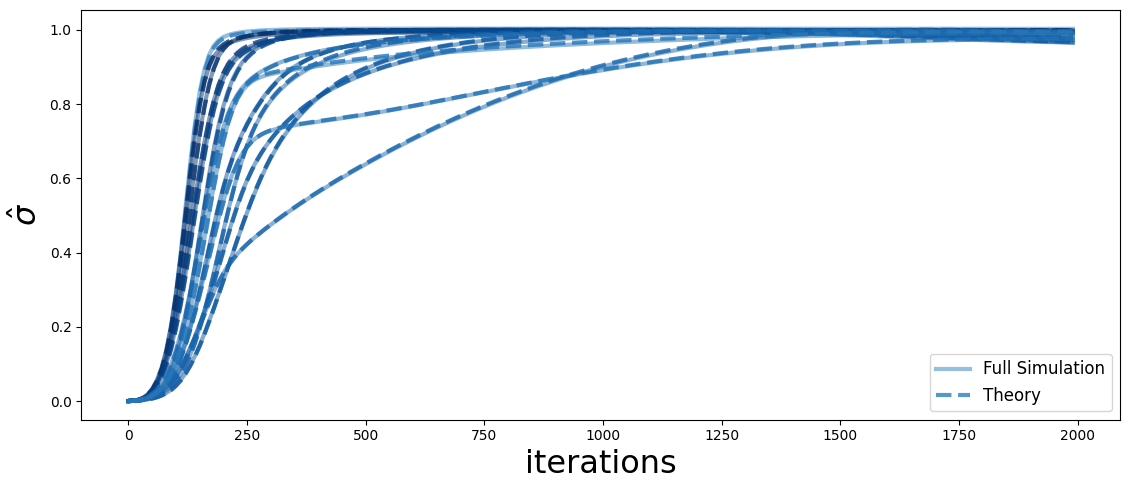

In [22]:
SimulationObj = TheorySimulator(n, k, m, U=U, V_t = V_t, sig_mat_io = sig_mat_io, rank=16, lr=4e-3, bw_lr=1.3e-3, lamb=1e-15, num_iterations=5000, update_QP=True, device='cuda')
singulars_sim, singulars_theory = np.array(SimulationObj.train(X = X, y=y))

fig, axs = plt.subplots(1, 1, figsize=(11.4, 5)) 
s = 14
lim = 200
# Create color mapsac
blue_colors = plt.cm.Blues(np.linspace(0.7, 1,s))
green_colors = plt.cm.Greens(np.linspace(0.65, 0.9,s))
red_colors = plt.cm.Reds(np.linspace(0.4, 1,s))

X_range = np.arange(len(singulars_sim[:, 0])) * 10

for j in range(s):
    # ax.plot(singulars_BP[i, :, j], color=blue_colors[j], label='BP' if j == 0 else "")
    axs.plot(X_range[:lim], singulars_sim[:lim, j] , color=blue_colors[-j], linewidth=3, alpha=0.5)
    axs.plot(X_range[:lim], singulars_theory[:lim, j] , color=blue_colors[-j], linewidth=3, alpha=0.8, linestyle='--')
    # axs.plot(X[:lim], singulars_FA[:lim, j]  , color=green_colors[0], linewidth=2, linestyle='--')

axs.set_xlabel('iterations', fontsize=23)
axs.set_ylabel('$\hat{\sigma}$', fontsize=23)
axs.legend(['Full Simulation', 'Theory'], loc='lower right', fontsize=12, ncol=1)

plt.tight_layout()
# plt.show()
plt.savefig('normative_approach_r_less_than_m_r_16.svg')

# Simulation for r < m with FA 

<>:21: SyntaxWarning: invalid escape sequence '\h'
<>:21: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_475385/2643680619.py:21: SyntaxWarning: invalid escape sequence '\h'
  axs.set_ylabel('$\hat{\sigma}$', fontsize=23)
100%|██████████| 5000/5000 [00:03<00:00, 1521.69it/s]


tensor(48.1495, device='cuda:0')


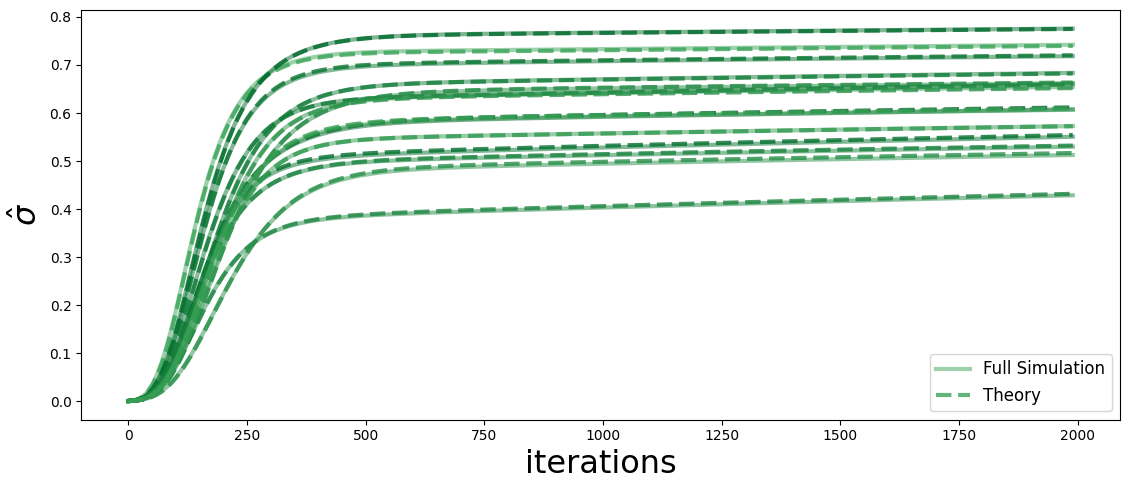

In [27]:
SimulationObj = TheorySimulator(n, k, m, U=U, V_t = V_t, sig_mat_io = sig_mat_io, rank=16, lr=4e-3, bw_lr=1.3e-3, lamb=1e-15, num_iterations=5000, update_QP=False, device='cuda')
singulars_sim, singulars_theory = np.array(SimulationObj.train(X = X, y=y))

fig, axs = plt.subplots(1, 1, figsize=(11.4, 5)) 
s = 14
lim = 200
# Create color mapsac
blue_colors = plt.cm.Blues(np.linspace(0.7, 1,s))
green_colors = plt.cm.Greens(np.linspace(0.65, 0.9,s))
red_colors = plt.cm.Reds(np.linspace(0.4, 1,s))

X_range = np.arange(len(singulars_sim[:, 0])) * 10

for j in range(s):
    # ax.plot(singulars_BP[i, :, j], color=blue_colors[j], label='BP' if j == 0 else "")
    axs.plot(X_range[:lim], singulars_sim[:lim, j] , color=green_colors[-j], linewidth=3, alpha=0.5)
    axs.plot(X_range[:lim], singulars_theory[:lim, j] , color=green_colors[-j], linewidth=3, alpha=0.8, linestyle='--')
    # axs.plot(X[:lim], singulars_FA[:lim, j]  , color=green_colors[0], linewidth=2, linestyle='--')

axs.set_xlabel('iterations', fontsize=23)
axs.set_ylabel('$\hat{\sigma}$', fontsize=23)
axs.legend(['Full Simulation', 'Theory'], loc='lower right', fontsize=12, ncol=1)

plt.tight_layout()
# plt.show()
plt.savefig('FA_r_less_than_m_r_16.svg')

<>:21: SyntaxWarning: invalid escape sequence '\h'
<>:21: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_475385/386536591.py:21: SyntaxWarning: invalid escape sequence '\h'
  axs.set_ylabel('$\hat{\sigma}$', fontsize=23)
100%|██████████| 5000/5000 [00:03<00:00, 1518.93it/s]


tensor(0.1368, device='cuda:0')


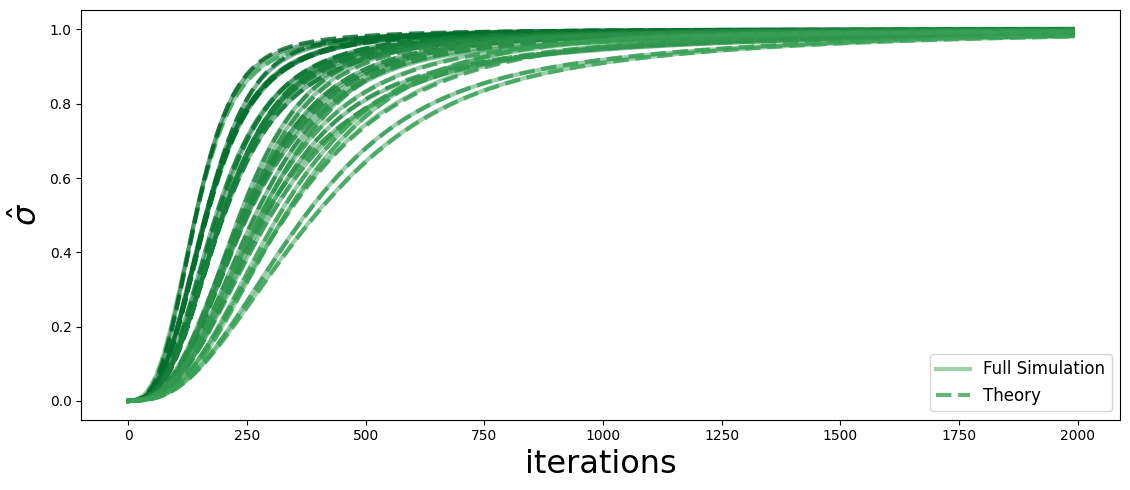

In [26]:
SimulationObj = TheorySimulator(n, k, m, U=U, V_t = V_t, sig_mat_io = sig_mat_io, rank=m, lr=4e-3, bw_lr=1.3e-3, lamb=1e-15, num_iterations=5000, update_QP=False, device='cuda')
singulars_sim, singulars_theory = np.array(SimulationObj.train(X = X, y=y))

fig, axs = plt.subplots(1, 1, figsize=(11.4, 5)) 
s = 32
lim = 200
# Create color mapsac
blue_colors = plt.cm.Blues(np.linspace(0.7, 1,s))
green_colors = plt.cm.Greens(np.linspace(0.65, 0.9,s))
red_colors = plt.cm.Reds(np.linspace(0.4, 1,s))

X_range = np.arange(len(singulars_sim[:, 0])) * 10

for j in range(s):
    # ax.plot(singulars_BP[i, :, j], color=blue_colors[j], label='BP' if j == 0 else "")
    axs.plot(X_range[:lim], singulars_sim[:lim, j] , color=green_colors[-j], linewidth=3, alpha=0.5)
    axs.plot(X_range[:lim], singulars_theory[:lim, j] , color=green_colors[-j], linewidth=3, alpha=0.8, linestyle='--')
    # axs.plot(X[:lim], singulars_FA[:lim, j]  , color=green_colors[0], linewidth=2, linestyle='--')

axs.set_xlabel('iterations', fontsize=23)
axs.set_ylabel('$\hat{\sigma}$', fontsize=23)
axs.legend(['Full Simulation', 'Theory'], loc='lower right', fontsize=12, ncol=1)

plt.tight_layout()
# plt.show()
plt.savefig('FA_r_less_than_m_equals_r.svg')

# LDFA TOP singular as function of ranks

In [ ]:
all_singulars_sim = []
all_singulars_theory = []
ranks = [1, 2, 4, 8, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32]

for rank in ranks:
    print(f"\n--- Running simulation for rank={rank} ---")
    SimulationObj = TheorySimulator(n, k, m, U=U, V_t = V_t, sig_mat_io = sig_mat_io, 
                                    rank=rank, lr=4e-3, bw_lr=1.3e-3, lamb=1e-15, num_iterations=5000, 
                                    update_QP=False, device='cuda')
    singulars_sim, singulars_theory = SimulationObj.train(X = X, y=y)
    
    all_singulars_sim.append(np.array(singulars_sim))
    all_singulars_theory.append(np.array(singulars_theory))

# Convert to numpy arrays for easier manipulation
all_singulars_sim = np.array(all_singulars_sim)  # Shape: (num_ranks, num_iterations, m)
all_singulars_theory = np.array(all_singulars_theory)  # Shape: (num_ranks, num_iterations, m)


--- Running simulation for rank=1 ---


  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [00:03<00:00, 1519.30it/s]


tensor(40.7812, device='cuda:0')

--- Running simulation for rank=2 ---


100%|██████████| 5000/5000 [00:03<00:00, 1524.99it/s]


...

tensor(3.0284, device='cuda:0')

--- Running simulation for rank=30 ---


100%|██████████| 5000/5000 [00:03<00:00, 1497.10it/s]


tensor(1.6180, device='cuda:0')

--- Running simulation for rank=32 ---


100%|██████████| 5000/5000 [00:03<00:00, 1497.11it/s]

tensor(0.1267, device='cuda:0')


<>:16: SyntaxWarning: invalid escape sequence '\h'
<>:16: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_477900/2083328652.py:16: SyntaxWarning: invalid escape sequence '\h'
  axs.set_ylabel('$\hat{\sigma}$', fontsize=23)


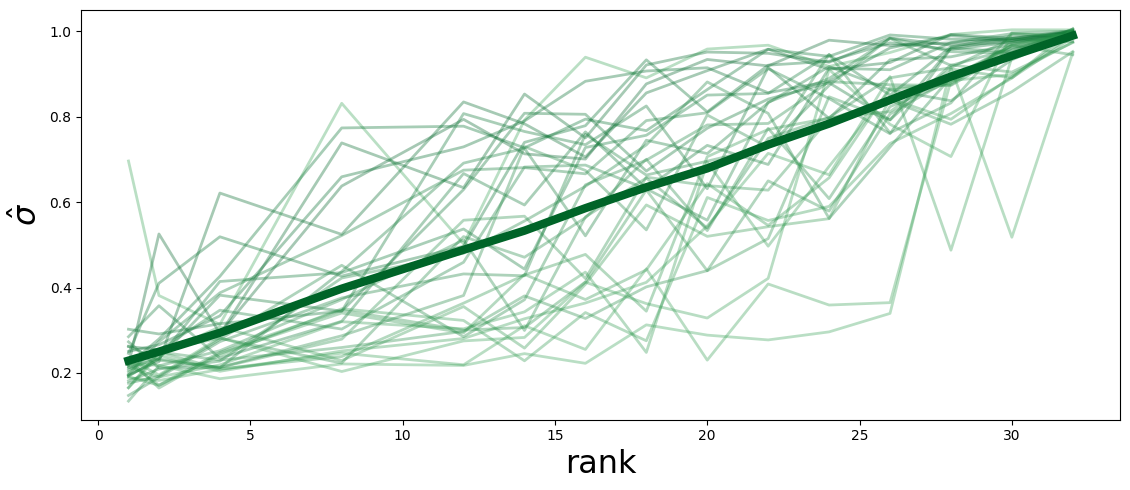

In [48]:
fig, axs = plt.subplots(1, 1, figsize=(11.4, 5)) 
s = 32
lim = 200
# Create color mapsac
blue_colors = plt.cm.Blues(np.linspace(0.7, 1,s))
green_colors = plt.cm.Greens(np.linspace(0.65, 0.9,s))
red_colors = plt.cm.Reds(np.linspace(0.4, 1,s))

for j in range(s):
    plt.plot(ranks, all_singulars_sim[:, -1, j], color=green_colors[-j], alpha=0.35, linewidth=2)

plt.plot(ranks, all_singulars_sim[:, -1, :s].mean(-1), color=green_colors[-1], linewidth=6)


axs.set_xlabel('rank', fontsize=23)
axs.set_ylabel('$\hat{\sigma}$', fontsize=23)
# axs.legend(['Full Simulation', 'Theory'], loc='lower right', fontsize=12, ncol=1)

plt.tight_layout()
# plt.show()
plt.savefig('FA_all_ranks.svg')

In [37]:
all_singulars_sim_trainbackward = []
all_singulars_theory_trainbackward = []
ranks = [1, 2, 4, 8, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32]

for rank in ranks:
    print(f"\n--- Running simulation for rank={rank} ---")
    SimulationObj = TheorySimulator(n, k, m, U=U, V_t = V_t, sig_mat_io = sig_mat_io, 
                                    rank=rank, lr=4e-3, bw_lr=1.3e-3, lamb=1e-15, num_iterations=5000, 
                                    update_QP=True, device='cuda')
    singulars_sim_trainbackward, singulars_theory = SimulationObj.train(X = X, y=y)
    
    all_singulars_sim_trainbackward.append(np.array(singulars_sim_trainbackward))
    all_singulars_theory_trainbackward.append(np.array(singulars_theory))

# Convert to numpy arrays for easier manipulation
all_singulars_sim_trainbackward = np.array(all_singulars_sim_trainbackward)  # Shape: (num_ranks, num_iterations, m)
all_singulars_theory_trainbackward = np.array(all_singulars_theory_trainbackward)  # Shape: (num_ranks, num_iterations, m)


--- Running simulation for rank=1 ---


100%|██████████| 5000/5000 [00:03<00:00, 1482.31it/s]


tensor(36.3205, device='cuda:0')

--- Running simulation for rank=2 ---


100%|██████████| 5000/5000 [00:03<00:00, 1445.87it/s]


tensor(28.6729, device='cuda:0')

--- Running simulation for rank=4 ---


...

tensor(0.6894, device='cuda:0')

--- Running simulation for rank=30 ---


100%|██████████| 5000/5000 [00:03<00:00, 1395.21it/s]


tensor(0.2914, device='cuda:0')

--- Running simulation for rank=32 ---


100%|██████████| 5000/5000 [00:03<00:00, 1396.94it/s]

tensor(7.5948e-06, device='cuda:0')


<>:16: SyntaxWarning: invalid escape sequence '\h'
<>:16: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_477900/1414151379.py:16: SyntaxWarning: invalid escape sequence '\h'
  axs.set_ylabel('$\hat{\sigma}$', fontsize=23)


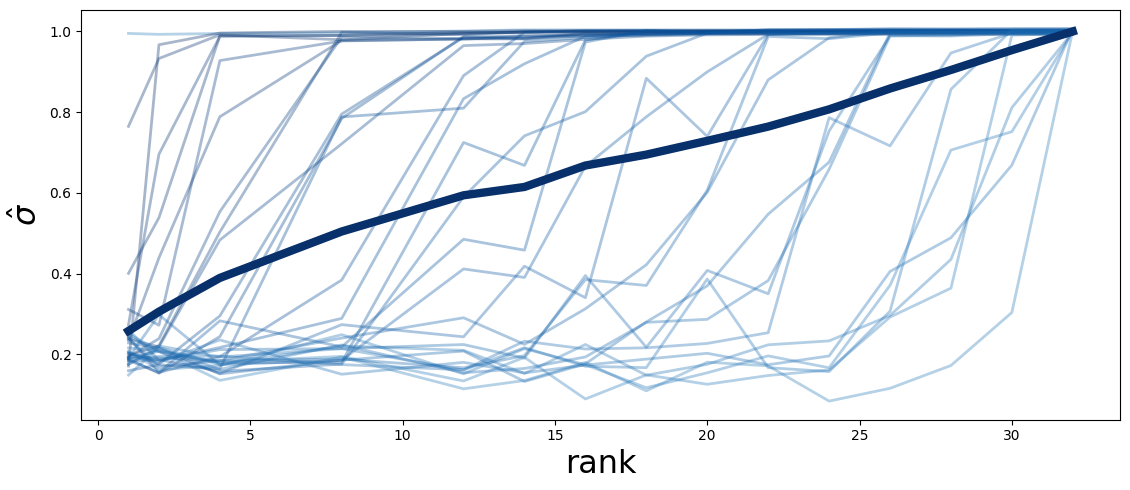

In [47]:
fig, axs = plt.subplots(1, 1, figsize=(11.4, 5)) 
s = 32
lim = 200
# Create color mapsac
blue_colors = plt.cm.Blues(np.linspace(0.7, 1,s))
green_colors = plt.cm.Greens(np.linspace(0.65, 0.9,s))
red_colors = plt.cm.Reds(np.linspace(0.4, 1,s))

for j in range(s):
    plt.plot(ranks, all_singulars_sim_trainbackward[:, -1, j], color=blue_colors[-j], alpha=0.35, linewidth=2)

plt.plot(ranks, all_singulars_sim_trainbackward[:, -1, :s].mean(-1), color=blue_colors[-1], linewidth=6)


axs.set_xlabel('rank', fontsize=23)
axs.set_ylabel('$\hat{\sigma}$', fontsize=23)
# axs.legend(['Full Simulation', 'Theory'], loc='lower right', fontsize=12, ncol=1)

plt.tight_layout()
# plt.show()
plt.savefig('LDFA_all_ranks.svg')